In [2]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

In [4]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [5]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])

base_specset = dmd.prep.SpecSetfromList(data)

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [18]:
n_trials = 100

rng = np.random.default_rng()
mc_specsets = []
for j in range(n_trials):
    new_specset = dmd.prep.SpecSetfromList(data)
    for i in range(base_specset.N_specs):
        new_specset.flux[i] = rng.normal(base_specset.flux[i], 
                                         base_specset.error[i])
    mc_specsets.append(new_specset)

(0.12, 0.2)

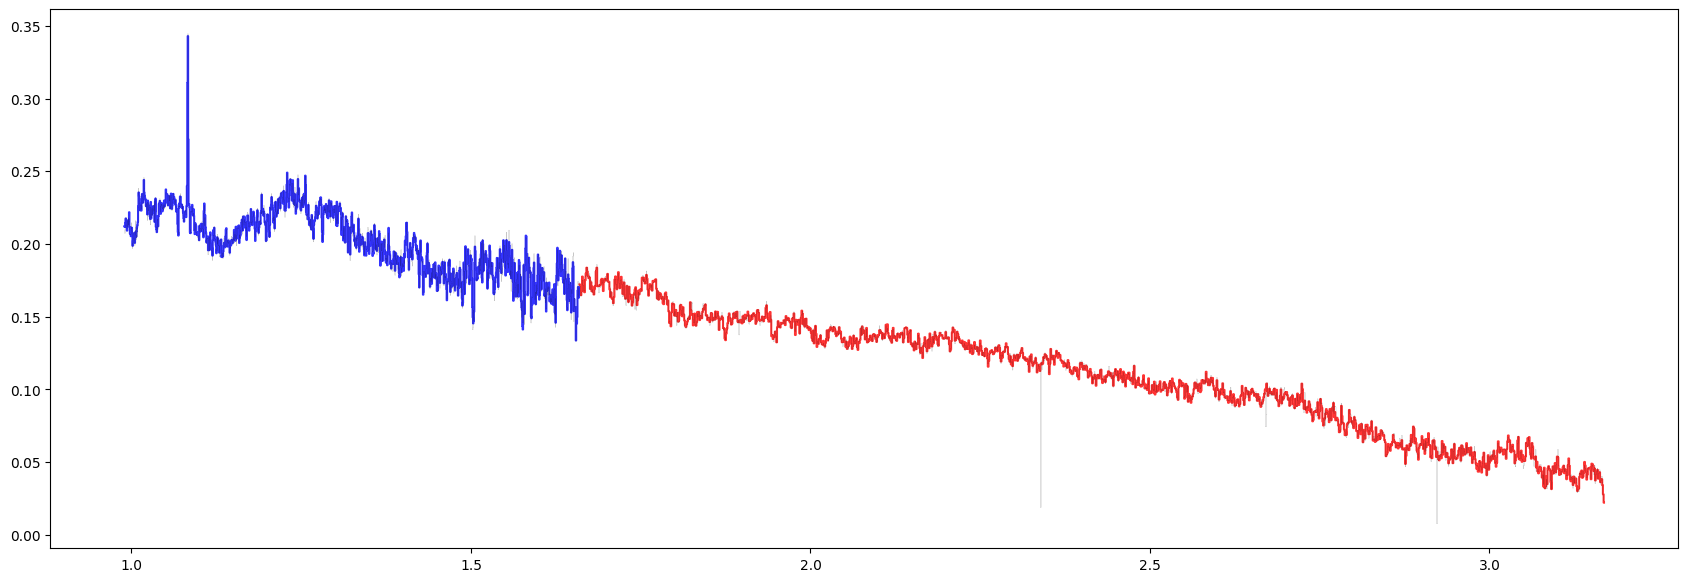

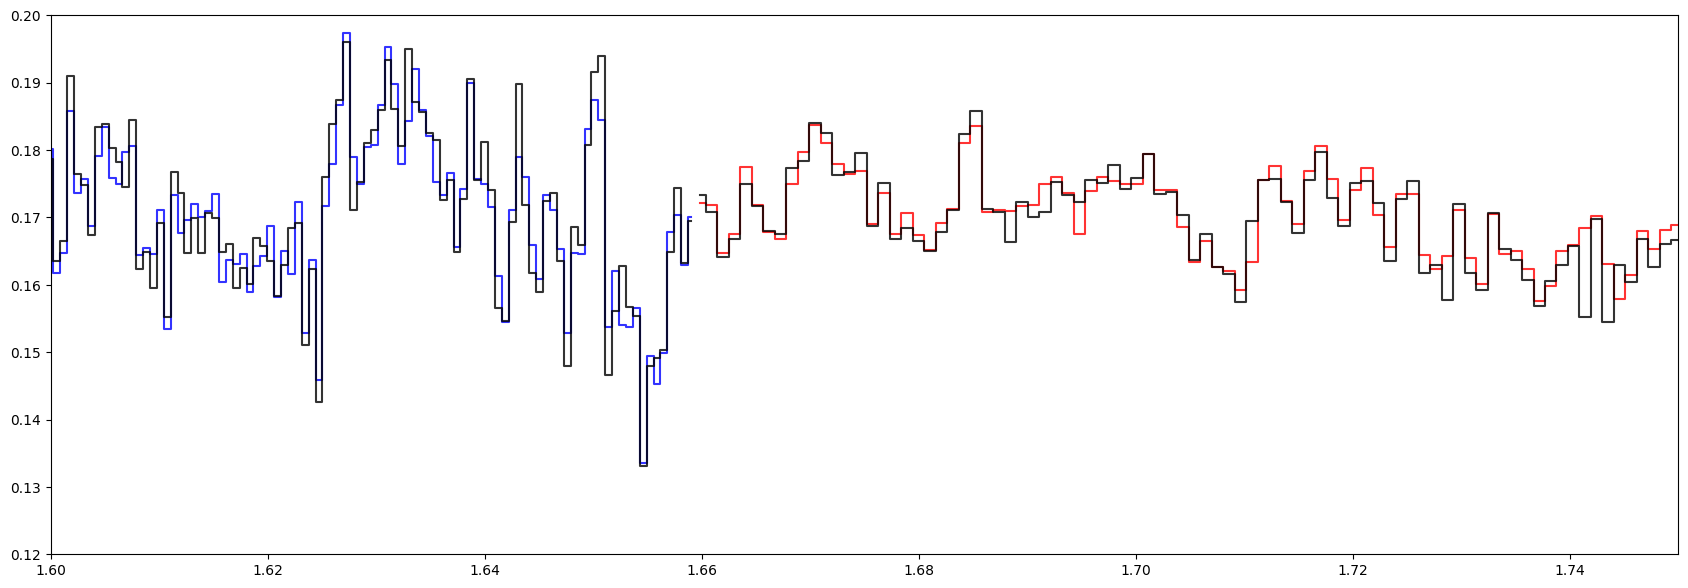

In [25]:
fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.8)
mc_specsets[0].plot(ax=ax, error_band=0, 
                    color='black', alpha=0.8, linewidth=0.1)

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.8)
mc_specsets[0].plot(ax=ax, error_band=0, color='black',
             alpha=0.8)
ax.set_xlim(1.6, 1.75)
ax.set_ylim(0.12, 0.2)